# Comparing VxE Effect

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import h5py
import scipy
from scipy.optimize import curve_fit

In [27]:
def readInOutputFile(outputFilename):
    optionsStructType = np.dtype([
        ('B0', np.float64, 3),
        ('E', np.float64, 3),
        ('L', np.float64, 3),
        ('yi', np.float64, 3),
        ('posHistBins', np.float64, 3),
        ('m', np.float64),
        ('t0', np.float64),
        ('tf', np.float64),
        ('rtol', np.float64),
        ('atol', np.float64),
        ('beta', np.float64),
        ('uround', np.float64),
        ('safe', np.float64),
        ('fac1', np.float64),
        ('fac2', np.float64),
        ('hmax', np.float64),
        ('h', np.float64),
        ('T', np.float64),
        ('gamma', np.float64),
        ('V', np.float64),
        ('swapStepSize', np.float64),
        ('ioutInt', np.float64),
        ('nmax', np.uint32),
        ('integratorType', np.int32),
        ('numParticles', np.int32),
        ('numPerGPUBlock', np.int32),
        ('iout', np.int32),
        ('numPhiBins', np.int32),
        ('numThetaBins', np.int32),
        ('dist', 'S', 1),
        ('output', 'S', 1),
        ('gas_coll', bool),
        ('diffuse', bool),
        ('gravity', bool),
        ('pad', 'S', 7) #this is padding space just designed to fix the structure padding done in C++
    ])
    file = open(outputFilename, 'rb')
    parameters = np.fromfile(file, count=1, dtype=optionsStructType)[0]
    data = None
    if parameters['output'] == b'n':
        #in this case it was the full dump of all particle data
        outputDtype = np.dtype([
            ('t', '<f8'),
            ('xx', '<f8'),
            ('xy', '<f8'),
            ('xz', '<f8'),
            ('sx', '<f8'),
            ('sy', '<f8'),
            ('sz', '<f8')])
        file.seek(0, 0)
        data = np.fromfile(file, dtype=outputDtype, offset=parameters.nbytes)
        numTimes = data.shape[0]//parameters['numParticles']
        numPer = int((parameters['tf']-parameters['t0'])/parameters['ioutInt'])+1
        data = data[:numTimes*parameters['numParticles']].reshape(-1, parameters['numParticles']).T #this returns the data in a little more convenient format, I think
    elif parameters['output'] == b'h':
        #this is the histogram output format instead now
        numx = int(parameters['L'][0]/parameters['gridSize'])+1
        numy = int(parameters['L'][1]/parameters['gridSize'])+1
        numz = int(parameters['L'][2]/parameters['gridSize'])+1

        numVecBins = int(np.ceil(2.0/parameters['vecBinSize']))

        xbins = np.arange(-parameters['L'][0]/2.0, parameters['L'][0]/2.0, parameters['gridSize'])
        ybins = np.arange(-parameters['L'][0]/2.0, parameters['L'][0]/2.0, parameters['gridSize']) 
        zbins = np.arange(-parameters['L'][0]/2.0, parameters['L'][0]/2.0, parameters['gridSize'])
        sbins = np.arange(-1.0, 1.0, parameters['vecBinSize'])
        outputDtype = np.dtype([
            ('t', np.float64),
            ('x', np.uint32, numx),
            ('y', np.uint32, numy),
            ('z', np.uint32, numz),
            ('sx', np.uint32, numVecBins),
            ('sy', np.uint32, numVecBins),
            ('sz', np.uint32, numVecBins)
        ])
        file.seek(0, 0)
        data = np.fromfile(file, dtype=outputDtype, offset=parameters.nbytes)
        data = {'xbins': xbins,
               'ybins': ybins,
               'zbins': zbins,
               'sbins': sbins,
               'data': data}
    elif parameters['output'] == b'a':
        outputDtype = np.dtype([
            ('t', np.float64),
            ('sx', np.float64),
            ('dsx', np.float64),
            ('sy', np.float64),
            ('dsy', np.float64),
            ('sz', np.float64),
            ('dsz', np.float64)
        ])
        file.seek(0, 0)
        data = np.fromfile(file, dtype=outputDtype, offset=parameters.nbytes)
    file.close()
    return parameters, data

def shiftDatapoints(phis):
    shifted = np.copy(phis)
    initHist, bins = np.histogram(phis, bins = 1000) #calculate the initial histogram and then adjust based on the mode
    peakloc = np.argmax(initHist)
    location = bins[peakloc]
    #shift everything to be close to that peak
    lowLocs = shifted<=(location-np.pi)
    highLocs = shifted>=(location+np.pi)
    shifted[lowLocs] += 2.0*np.pi
    shifted[highLocs] -= 2.0*np.pi
    mean = np.nanmean(shifted)
    std = np.nanstd(shifted)
    shifted[shifted<(mean-std*5)] = np.nan
    shifted[shifted>(mean+std*5)] = np.nan
    return shifted

def analyzeDataset(dset, randomSample = False, plot=False):
    times = np.sort(np.unique(dset[0]['t']))
    phis = np.arctan2(dset['sy'], dset['sz'])
    for i in range(len(times)):
        if randomSample:
            phis[:,i] = shiftDatapoints(np.random.choice(phis[:,i], size=phis[:,i].shape))
        else:
            phis[:,i] = shiftDatapoints(phis[:,i])
        if plot:
            plt.hist(phis[:,i], bins = 1000)
            plt.title(times[i])
            plt.yscale('log')
            plt.show()
    means = np.nanmean(phis, axis=0)
    stds = np.nanstd(phis, axis=0)
    return times, means, stds

def bootstrapResults(dset, numBootstrap):
    times = []
    means = []
    stds = []
    for i in range(numBootstrap):
        print(i)
        time, mean, std = analyzeDataset(dset, randomSample=True)
        times.append(time)
        means.append(mean)
        stds.append(std)
    times = times[0]
    means = np.array(means)
    stds = np.array(stds)
    return times, means, stds

## Analyze the No Field Dataset

In [3]:
#load in the no electric field dataset

directory = '/storage/home/hcoda1/9/dmathews33/scratch/noEField/wrongVelocity/'
allFiles = os.listdir(directory)
sizes = []
for f in allFiles:
    sizes.append(os.stat(directory + f).st_size)
sizes = np.array(sizes)
maxSize = max(sizes)

totalSize = 0
original = []
for f in allFiles:
    if os.stat(directory + f).st_size == maxSize:
        totalSize += maxSize
        original.append(directory + f)
print(totalSize//(1024 * 1024))

parametersNoField = []
datasetNoField = []
for f in original:
    temp = readInOutputFile(f)
    parametersNoField.append(temp[0])
    datasetNoField.append(temp[1])
parametersNoField = np.array(parametersNoField)
datasetNoField = np.concatenate(np.array(datasetNoField), axis=0)

18296


In [4]:
resultsNoField = analyzeDataset(datasetNoField)

## Analyze the Full Field Dataset from RK45

In [5]:
#load in the full electric field dataset

directory = '/storage/home/hcoda1/9/dmathews33/scratch/fullEField/rightVelocityAndMass/RK45Quat/'
allFiles = os.listdir(directory)
sizes = []
for f in allFiles:
    sizes.append(os.stat(directory + f).st_size)
sizes = np.array(sizes)
maxSize = max(sizes)

totalSize = 0
original = []
for f in allFiles:
    if os.stat(directory + f).st_size == maxSize:
        totalSize += maxSize
        original.append(directory + f)
print(totalSize//(1024 * 1024))

parametersFullField = []
datasetFullField = []
for f in original:
    temp = readInOutputFile(f)
    parametersFullField.append(temp[0])
    datasetFullField.append(temp[1])
parametersFullField = np.array(parametersFullField)
datasetFullField = np.concatenate(np.array(datasetFullField), axis=0)
numPartsFullField = datasetFullField.shape[0]

19193


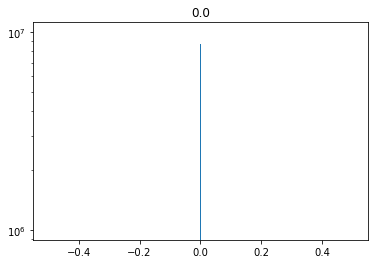

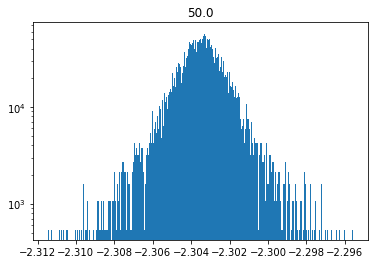

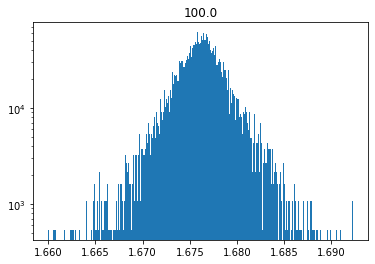

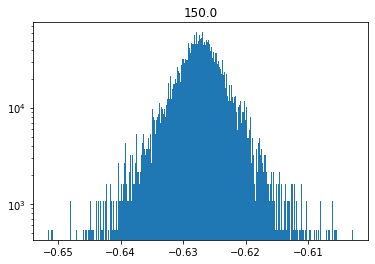

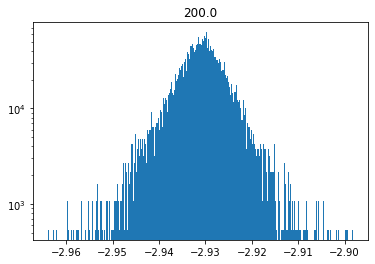

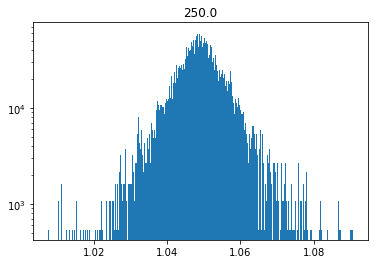

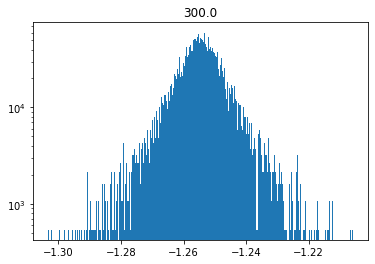

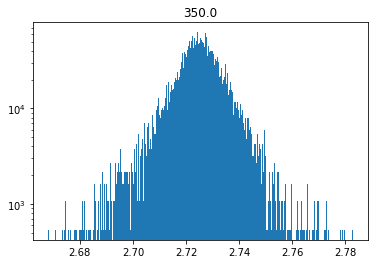

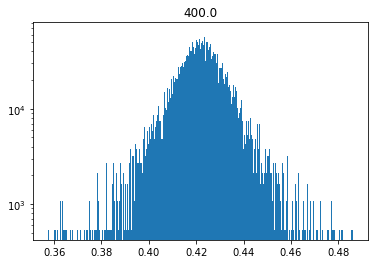

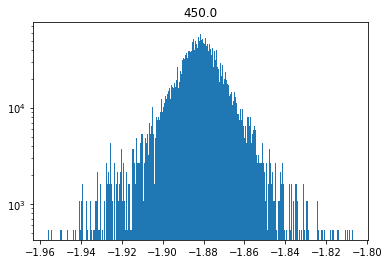

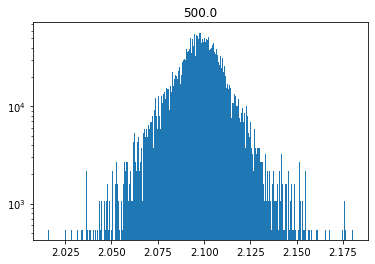

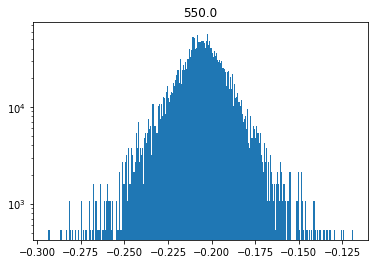

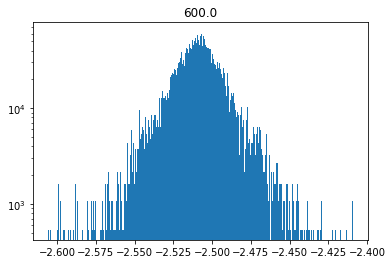

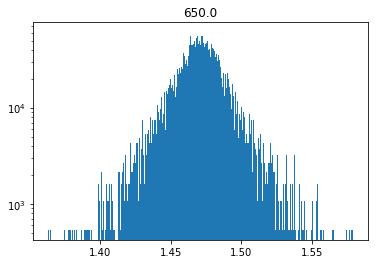

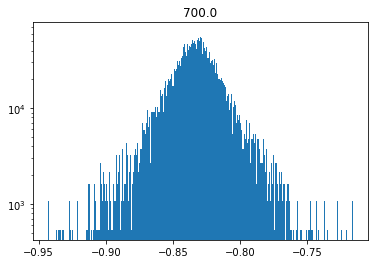

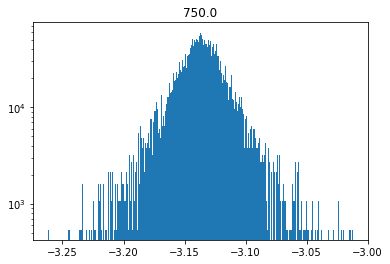

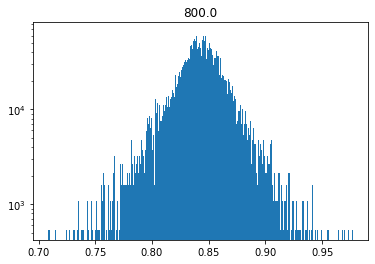

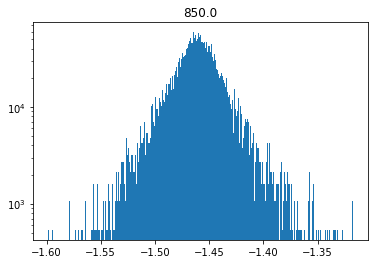

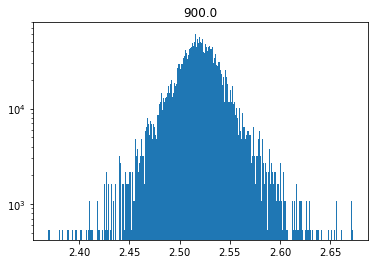

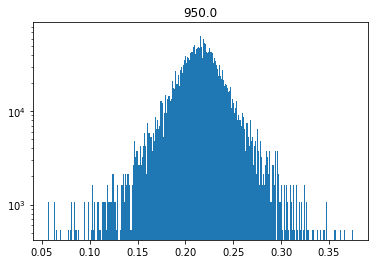

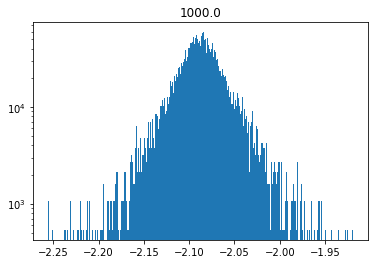

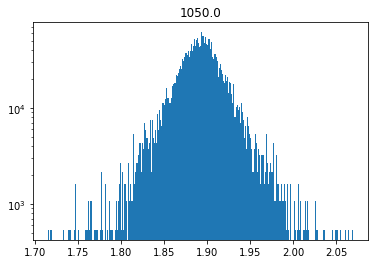

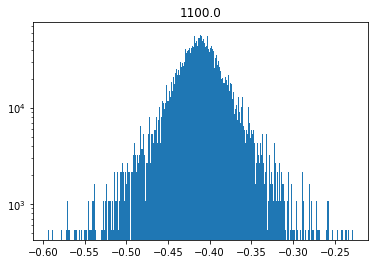

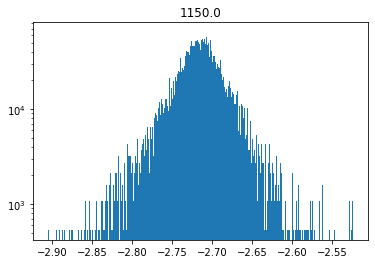

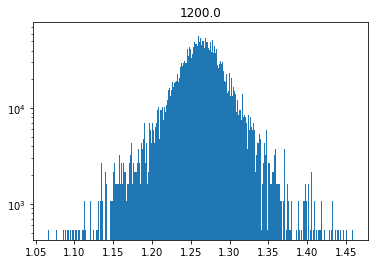

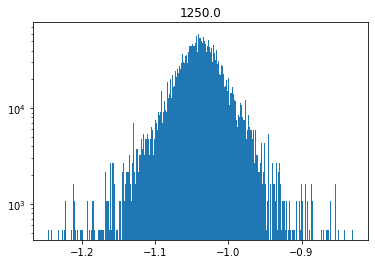

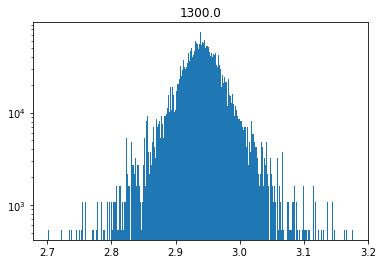

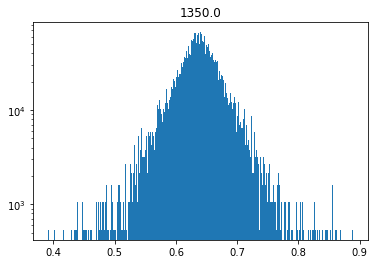

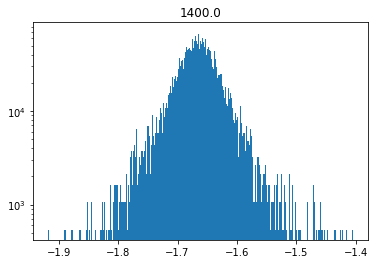

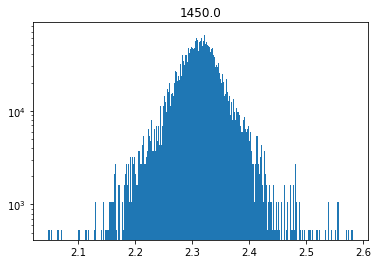

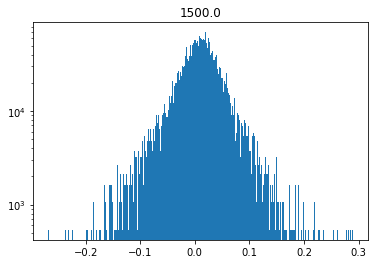

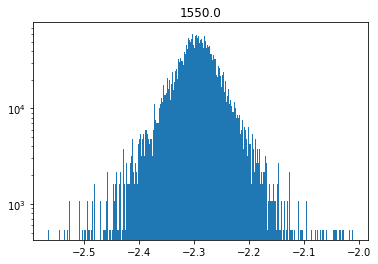

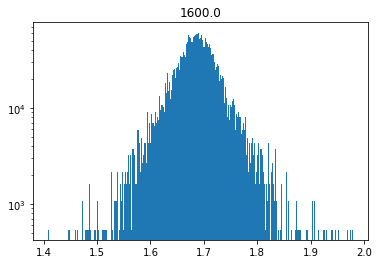

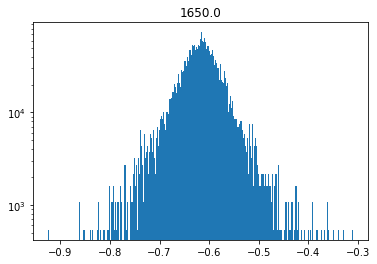

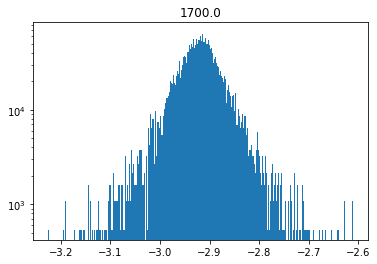

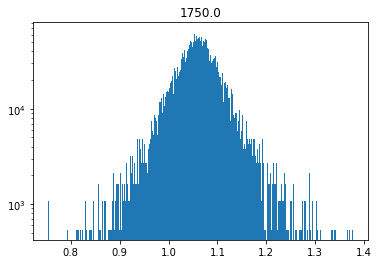

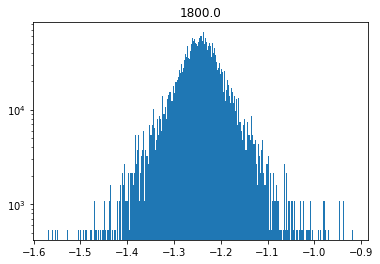

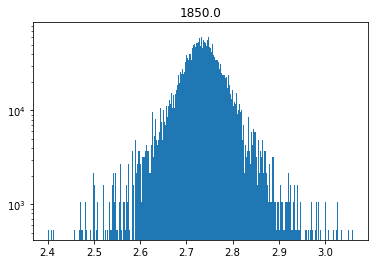

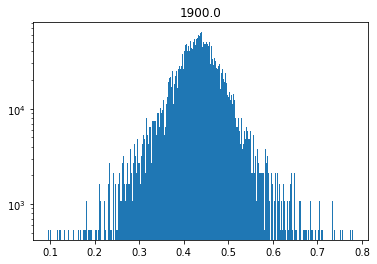

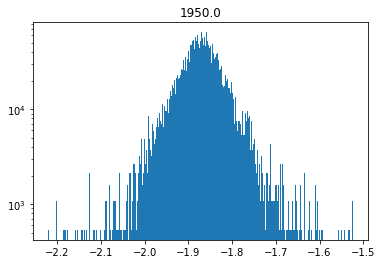

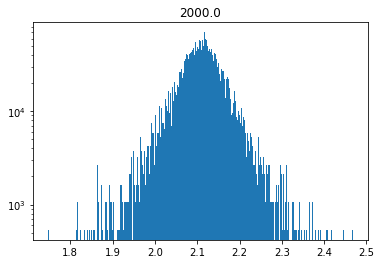

In [6]:
resultsFullField = analyzeDataset(datasetFullField, plot=True)

## Full Field with DOP853

In [7]:
#load in the full electric field dataset

directory = '/storage/home/hcoda1/9/dmathews33/scratch/fullEField/rightVelocityAndMass/DOP853/'
allFiles = os.listdir(directory)
sizes = []
for f in allFiles:
    sizes.append(os.stat(directory + f).st_size)
sizes = np.array(sizes)
maxSize = max(sizes)

totalSize = 0
original = []
for f in allFiles:
    if os.stat(directory + f).st_size == maxSize:
        totalSize += maxSize
        original.append(directory + f)
print(totalSize//(1024 * 1024))

parametersFullFieldDOP = []
datasetFullFieldDOP = []
for f in original:
    temp = readInOutputFile(f)
    parametersFullFieldDOP.append(temp[0])
    datasetFullFieldDOP.append(temp[1])
parametersFullFieldDOP = np.array(parametersFullFieldDOP)
datasetFullFieldDOP = np.concatenate(np.array(datasetFullFieldDOP), axis=0)
numPartsFullFieldDOP = datasetFullFieldDOP.shape[0]

6708


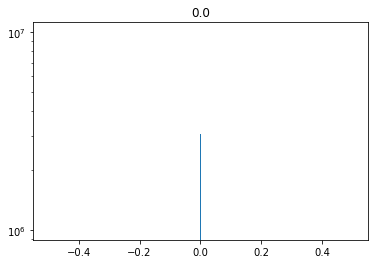

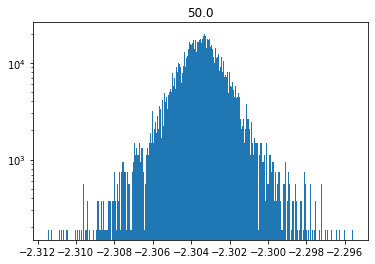

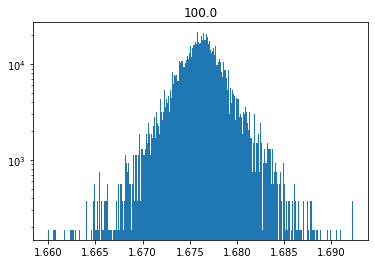

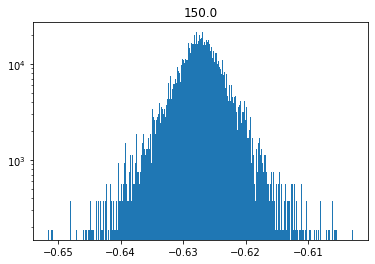

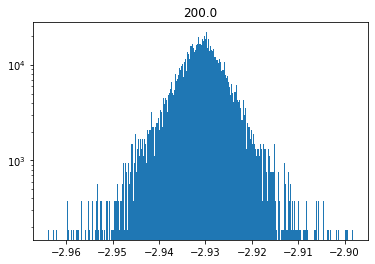

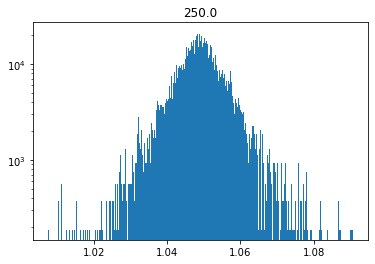

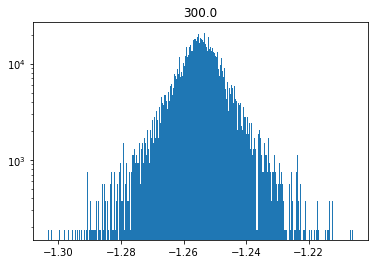

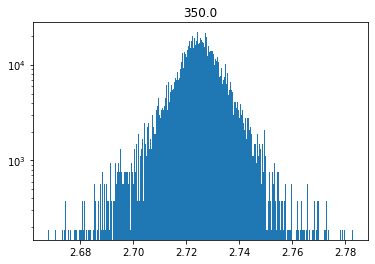

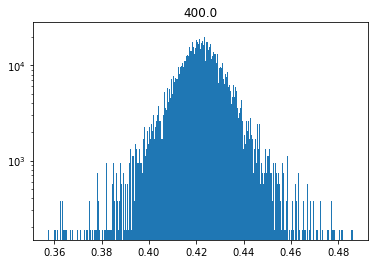

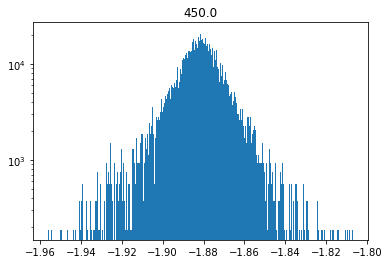

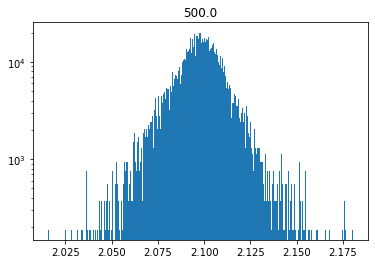

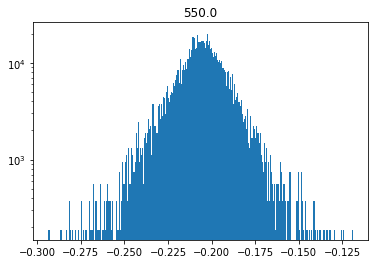

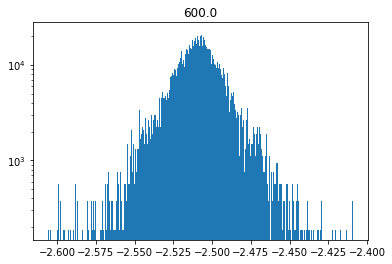

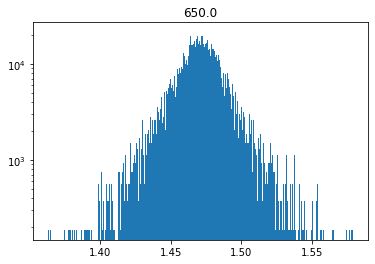

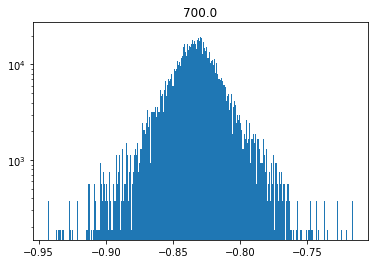

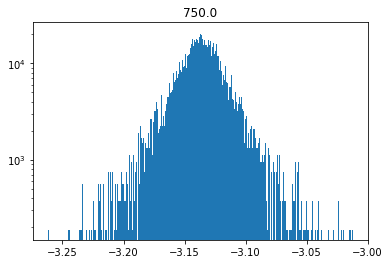

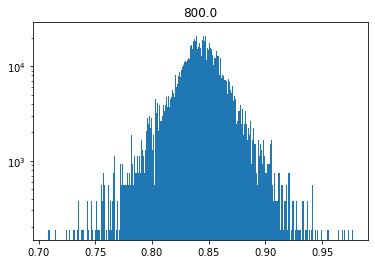

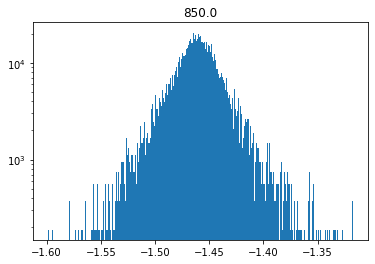

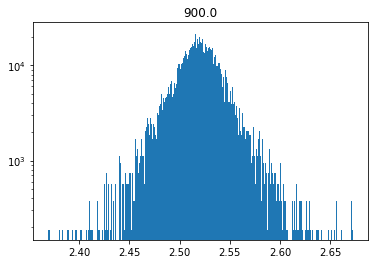

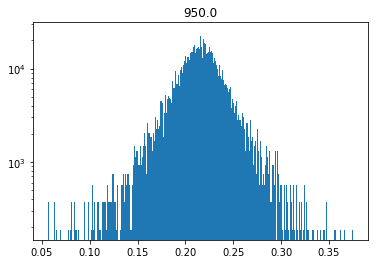

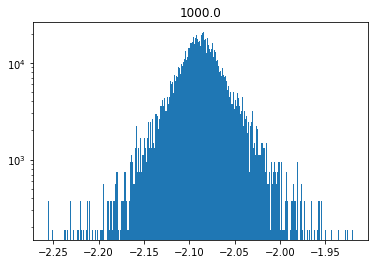

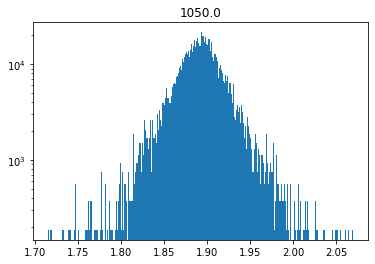

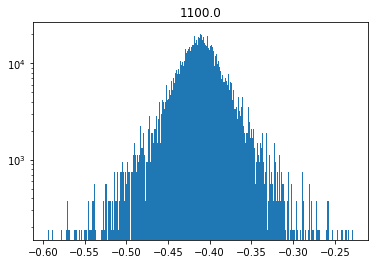

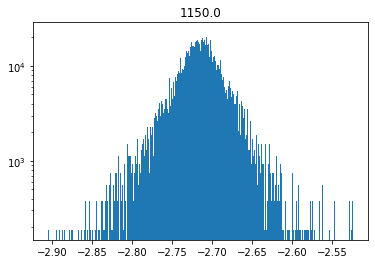

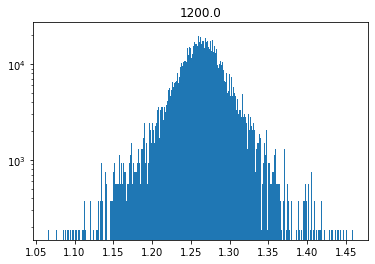

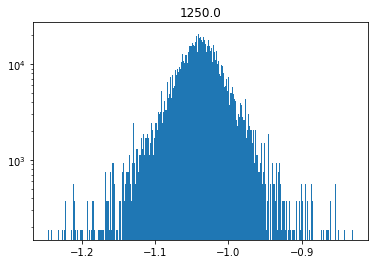

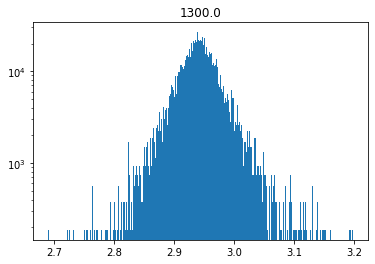

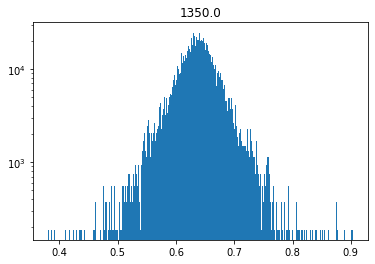

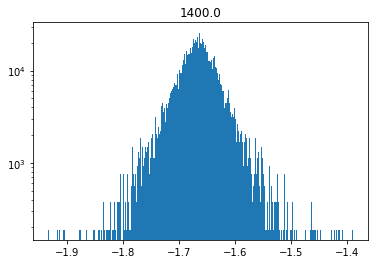

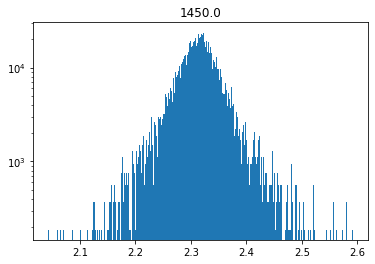

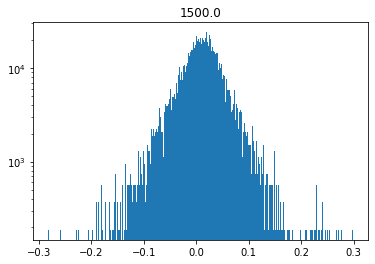

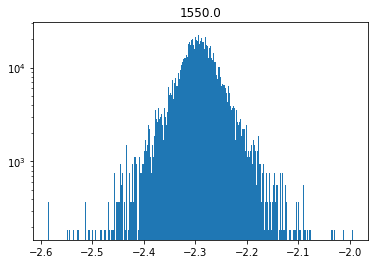

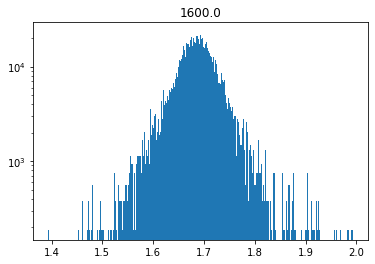

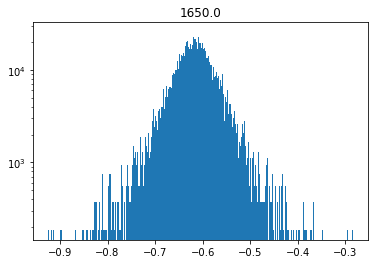

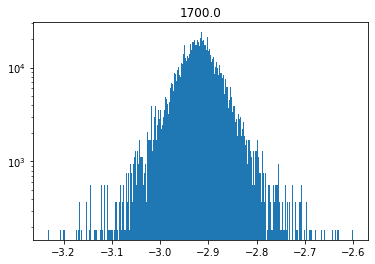

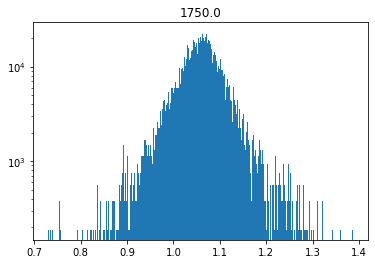

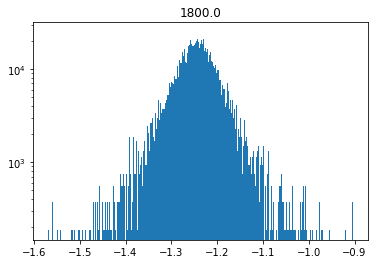

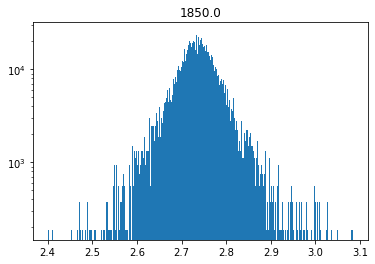

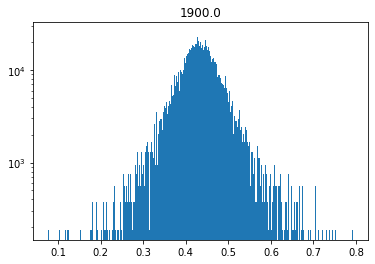

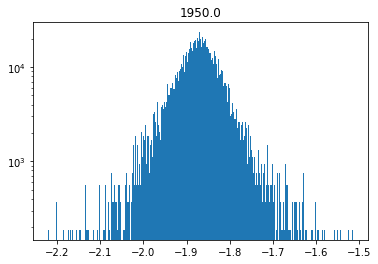

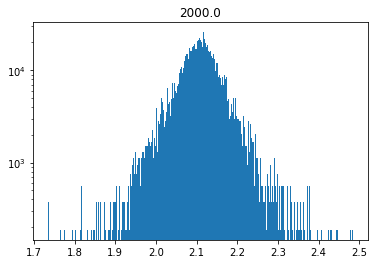

In [8]:
resultsFullFieldDOP = analyzeDataset(datasetFullFieldDOP, plot=True)

## Full Field with RK45 CPU

In [28]:
#load in the full electric field dataset

directory = '/storage/home/hcoda1/9/dmathews33/scratch/fullEField/rightVelocityAndMass/RK45CPU/'
allFiles = os.listdir(directory)
sizes = []
for f in allFiles:
    sizes.append(os.stat(directory + f).st_size)
sizes = np.array(sizes)
maxSize = max(sizes)

totalSize = 0
original = []
for f in allFiles:
    if os.stat(directory + f).st_size == maxSize:
        totalSize += maxSize
        original.append(directory + f)
print(totalSize//(1024 * 1024))

parametersFullFieldRK45CPU = []
datasetFullFieldRK45CPU = []
for f in original:
    temp = readInOutputFile(f)
    parametersFullFieldRK45CPU.append(temp[0])
    datasetFullFieldRK45CPU.append(temp[1])
parametersFullFieldRK45CPU = np.array(parametersFullFieldRK45CPU)
datasetFullFieldRK45CPU = np.concatenate(np.array(datasetFullFieldRK45CPU), axis=0)
numPartsFullFieldRK45CPU = datasetFullFieldRK45CPU.shape[0]

24


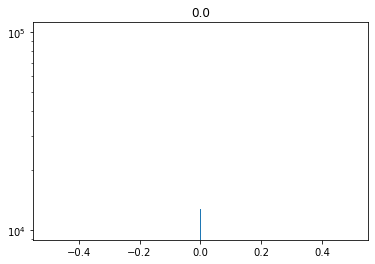

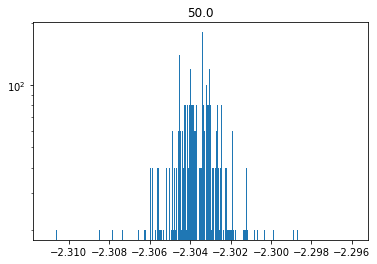

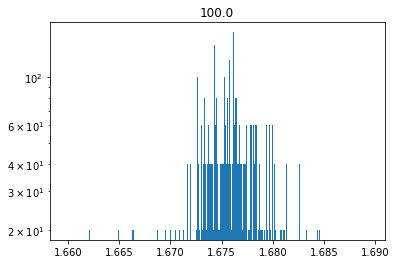

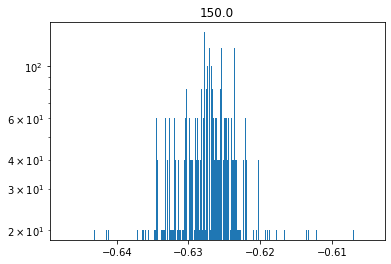

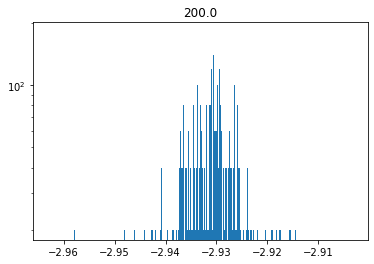

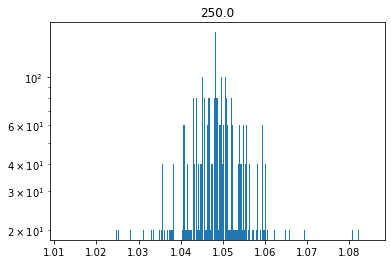

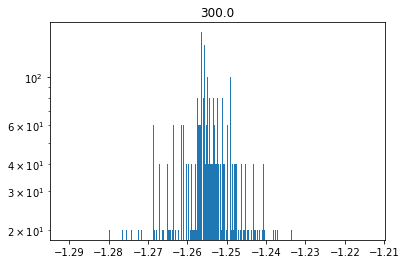

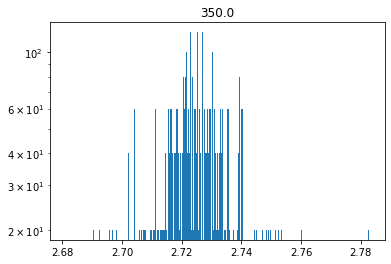

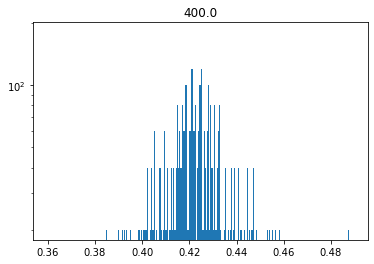

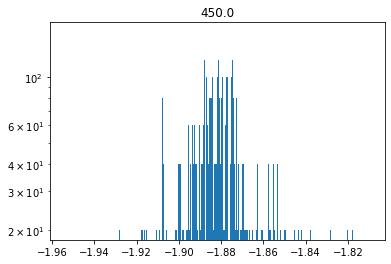

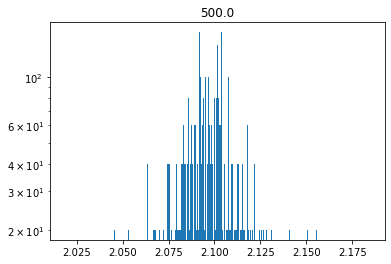

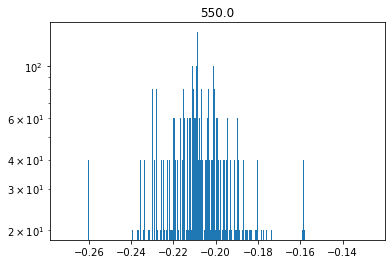

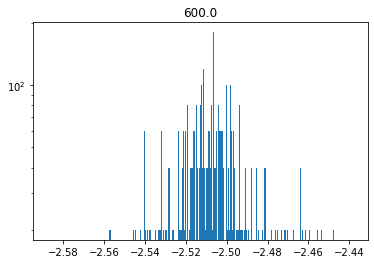

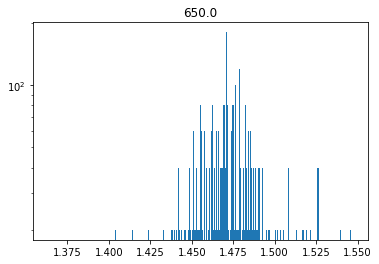

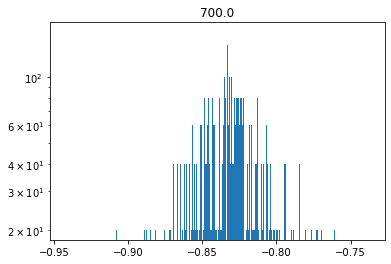

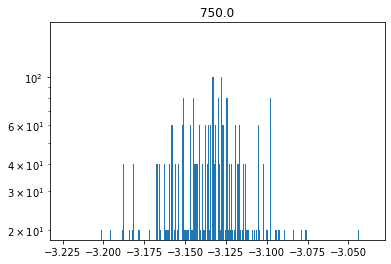

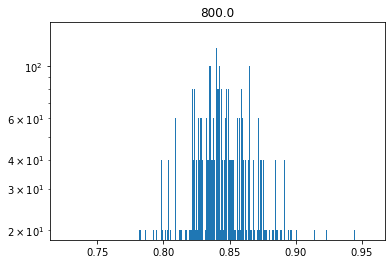

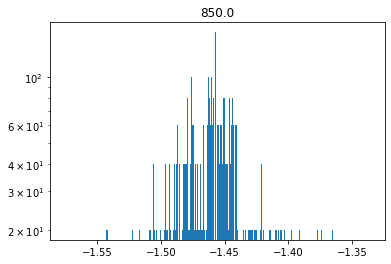

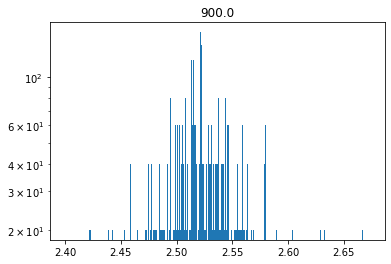

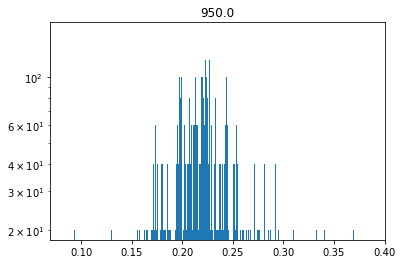

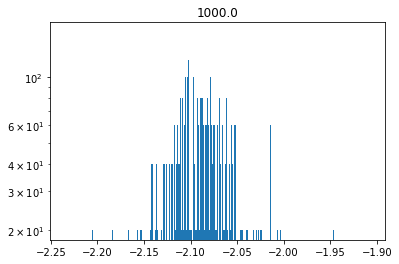

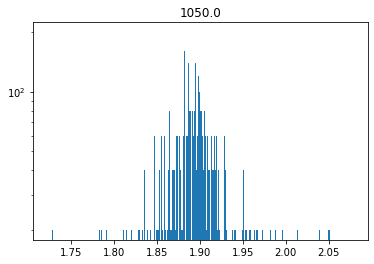

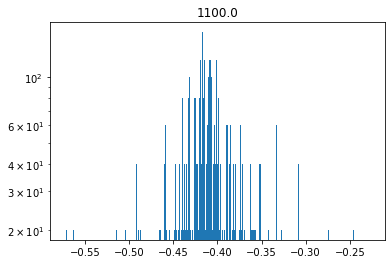

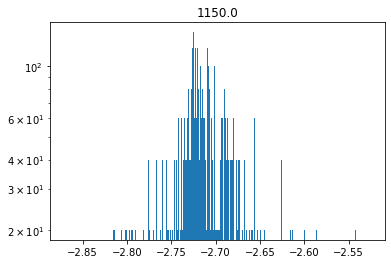

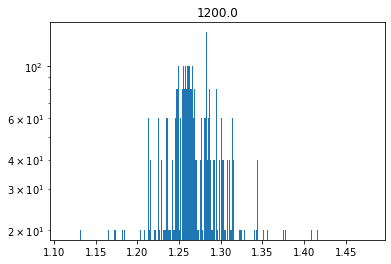

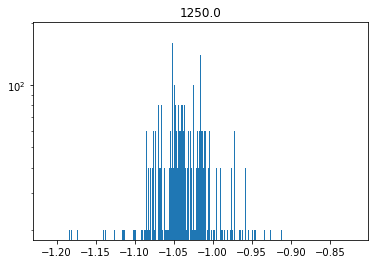

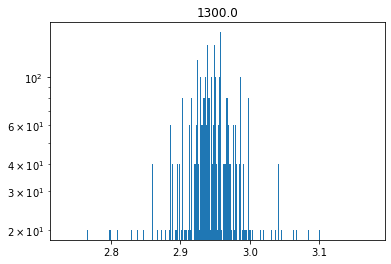

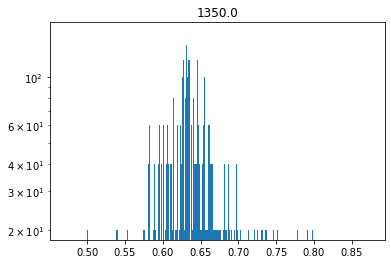

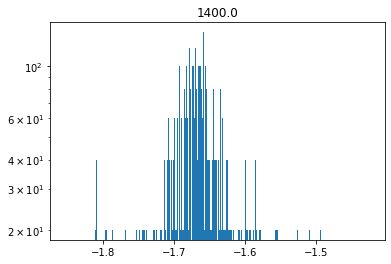

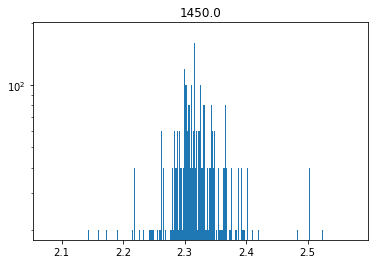

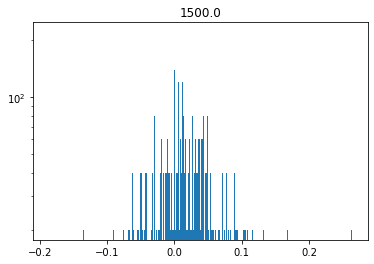

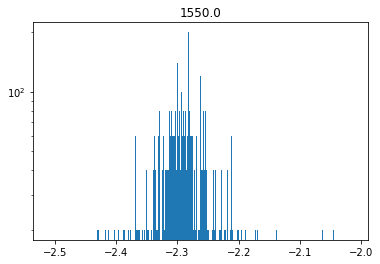

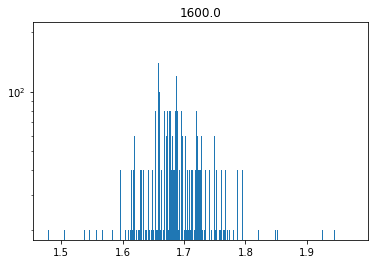

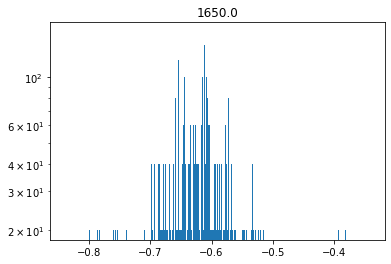

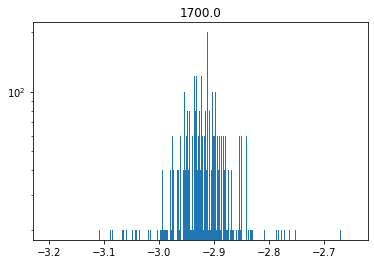

In [34]:
resultsFullFieldRK45CPU = analyzeDataset(datasetFullFieldRK45CPU, plot=True)

## Compare and Contrast these results

In [35]:
print(parametersNoField['E'][0])
print(parametersFullField['E'][0])

[0. 0. 0.]
[7500000.       0.       0.]


-611.4 0.010276717872390557


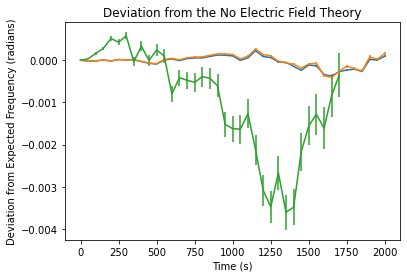

<ipython-input-42-0ce6a7a47d66>:39: RuntimeWarning: invalid value encountered in true_divide
  plt.errorbar(times[locs], deviationsFullField[locs]/times[locs]/(2.0*np.pi)*1e9, label='RK45 Quaternion', yerr=1e9*resultsFullField[2][locs]/np.sqrt(numPartsFullField)/(2.0*np.pi*times[locs]))
<ipython-input-42-0ce6a7a47d66>:40: RuntimeWarning: invalid value encountered in true_divide
  plt.errorbar(times[locs], deviationsFullFieldDOP[locs]/times[locs]/(2.0*np.pi)*1e9, label='DOP853', yerr=1e9*resultsFullFieldDOP[2][locs]/np.sqrt(numPartsFullFieldDOP)/(2.0*np.pi*times[locs]))


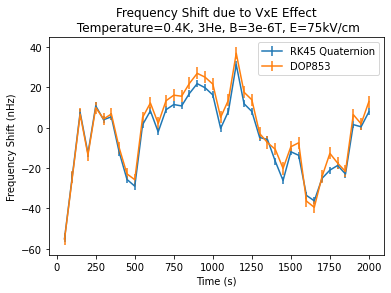

In [42]:
times = np.copy(resultsFullField[0])
locs = np.arange(len(times))
w = parametersFullField[0]['gamma']*np.sqrt(np.sum(np.square(parametersNoField[0]['B0']))) #calculate the frequency
period = abs(2.0*np.pi/w) #calculate the period of the oscillation
print(w, period)
locationInPeriod = (times/period)%1
trueAngle = locationInPeriod*2.0*np.pi

deviationsNoField = np.copy(resultsNoField[1])
deviationsNoField[deviationsNoField<0] += np.pi*2.0
deviationsNoField[deviationsNoField>0] = 2.0*np.pi - deviationsNoField[deviationsNoField>0]
deviationsNoField = np.subtract(deviationsNoField, trueAngle)[:]

deviationsFullField = np.copy(resultsFullField[1])
deviationsFullField[deviationsFullField<0] += np.pi*2.0
deviationsFullField[deviationsFullField>0] = 2.0*np.pi - deviationsFullField[deviationsFullField>0]
deviationsFullField = np.subtract(deviationsFullField, trueAngle)[:]

deviationsFullFieldDOP = np.copy(resultsFullFieldDOP[1])
deviationsFullFieldDOP[deviationsFullFieldDOP<0] += np.pi*2.0
deviationsFullFieldDOP[deviationsFullFieldDOP>0] = 2.0*np.pi - deviationsFullFieldDOP[deviationsFullFieldDOP>0]
deviationsFullFieldDOP = np.subtract(deviationsFullFieldDOP, trueAngle)[:]

deviationsFullFieldCPU = np.copy(resultsFullFieldRK45CPU[1])
deviationsFullFieldCPU[deviationsFullFieldCPU<0] += np.pi*2.0
deviationsFullFieldCPU[deviationsFullFieldCPU>0] = 2.0*np.pi - deviationsFullFieldCPU[deviationsFullFieldCPU>0]
deviationsFullFieldCPU = np.subtract(deviationsFullFieldCPU, trueAngle[:-6])[:]

#plt.errorbar(times, deviationsNoField, yerr=resultsNoField[2]/np.sqrt(datasetNoField.shape[0]))
#plt.errorbar(times, deviationsMidField, yerr=resultsMidField[2]/np.sqrt(datasetMidField.shape[0]))
plt.errorbar(resultsFullField[0], deviationsFullField, yerr=resultsFullField[2]/np.sqrt(numPartsFullField))
plt.errorbar(resultsFullFieldDOP[0], deviationsFullFieldDOP, yerr=resultsFullField[2]/np.sqrt(numPartsFullFieldDOP))
plt.errorbar(resultsFullFieldRK45CPU[0], deviationsFullFieldCPU, yerr=resultsFullFieldRK45CPU[2]/np.sqrt(numPartsFullFieldRK45CPU))
plt.xlabel('Time (s)')
plt.ylabel('Deviation from Expected Frequency (radians)')
plt.title('Deviation from the No Electric Field Theory')
plt.show()

plt.errorbar(times[locs], deviationsFullField[locs]/times[locs]/(2.0*np.pi)*1e9, label='RK45 Quaternion', yerr=1e9*resultsFullField[2][locs]/np.sqrt(numPartsFullField)/(2.0*np.pi*times[locs]))
plt.errorbar(times[locs], deviationsFullFieldDOP[locs]/times[locs]/(2.0*np.pi)*1e9, label='DOP853', yerr=1e9*resultsFullFieldDOP[2][locs]/np.sqrt(numPartsFullFieldDOP)/(2.0*np.pi*times[locs]))
plt.xlabel('Time (s)')
plt.ylabel('Frequency Shift (nHz)')
plt.title('Frequency Shift due to VxE Effect\n Temperature=0.4K, 3He, B=3e-6T, E=75kV/cm')
plt.legend()
plt.show()

In [107]:
print(numPartsFullField, numPartsFullFieldDOP)

8765440 1359872


In [91]:
fitResNoField = np.polyfit(times, deviationsNoField/(2.0*np.pi), deg=1, cov=True)
fitResFullField = np.polyfit(times[locs], deviationsFullField[locs]/(2.0*np.pi), deg=1, cov=True)
fitResFullFieldDOP = np.polyfit(times[locs], deviationsFullFieldDOP[locs]/(2.0*np.pi), deg=1, cov=True)

In [92]:
print('Drift No Field:', fitResNoField[0], np.sqrt(np.diag(fitResNoField[1])))
print('Drift Full Field:', fitResFullField[0], np.sqrt(np.diag(fitResFullField[1])))
print('Drift Full Field DOP:', fitResFullFieldDOP[0], np.sqrt(np.diag(fitResFullFieldDOP[1])))

Drift No Field: [-3.26689602e-05  1.39372824e-02] [1.05447296e-04 1.22518686e-01]
Drift Full Field: [-1.44284771e-08  8.81462348e-06] [5.16557103e-09 6.00185118e-06]
Drift Full Field DOP: [-1.15307357e-08  9.24854609e-06] [5.70935344e-09 6.63366924e-06]


In [78]:
datasetFullField.shape

(10780672, 41)